<a href="https://colab.research.google.com/github/salahibra/computer_vision/blob/main/04_first_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP : Construire un premier CNN sur Fashion-MNIST

Ce TP vous amène à mettre en place l'ensemble du pipeline d'un réseau convolutionnel simple appliqué à Fashion-MNIST : exploration des données, vectorisation, architecture CNN, apprentissage supervisé et analyse des performances.


### Préparer l'environnement d'apprentissage convolutionnel

Importez toutes les bibliothèques nécessaires : `matplotlib.pyplot` pour la visualisation, `torch` et `torch.nn` pour la construction du modèle, `torchvision.datasets` pour accéder à Fashion-MNIST, `torch.utils.data` (incluant `Dataset`, `DataLoader` et `random_split`) pour structurer les jeux de données, ainsi que `numpy`, `tqdm` et les métriques de `sklearn` utiles au suivi des performances.

In [1]:
import matplotlib.pyplot as plt
from torchvision import datasets
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np
from torch.utils.data import random_split
from tqdm import tqdm
from sklearn.metrics import classification_report
import os

### Charger le corpus Fashion-MNIST

Utilisez `datasets.FashionMNIST` pour télécharger la partie entraînement (`train=True`) du jeu de données dans le répertoire local, puis conservez l'objet `full_mnist` qui servira de base à toutes les manipulations ultérieures.

In [ ]:
data_dir = '../data/' ## mettez le votre
full_mnist = datasets.FashionMNIST(data_dir, download=True, train=True)

### Examiner visuellement un exemple du dataset

Implémentez la fonction `show_fmnist_image(dataset, idx)` qui doit :

- Extraire l'image et l'étiquette associées à l'indice `idx` du dataset fourni.
- Afficher l'image en niveaux de gris (dans `plt.show` -> `cmap='gray'`) avec comme titre le nom de la classe correspondante (utilisez `dataset.classes[label]`).
- Afficher la forme du tenseur image, la valeur minimale et maximale des pixels, ainsi que l'identifiant numérique et le nom de la classe.
- Tester la fonction sur un indice donné (par exemple `24300`) pour illustrer son fonctionnement.


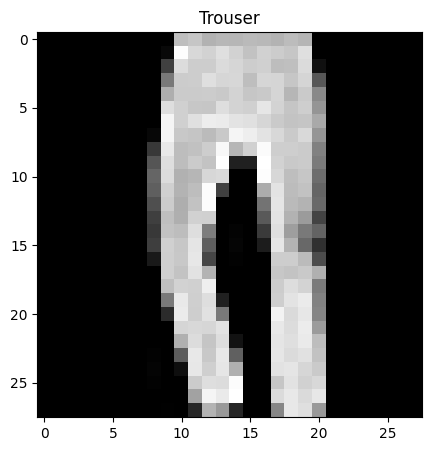

Image shape : torch.Size([28, 28])
Min value: 0
Max value: 255


In [ ]:
def show_fmnist_image(dataset, idx):
    img = dataset.data[idx]
    label = dataset.targets[idx].item()
    label_txt = dataset.classes[label]
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(label_txt)
    plt.show()
    print("Image shape :", img.shape)
    print("Min value:", img.min().item())
    print("Max value:", img.max().item())

show_fmnist_image(full_mnist, 24300)

### Inventorier les catégories disponibles

Affichez le nombre total de classes contenues dans `full_mnist.classes`, puis parcourez cette liste pour présenter chaque intitulé en l'associant à son identifiant numérique.


In [ ]:
print("FashionMNIST classes : %d" % len(full_mnist.classes))
for i, cls in enumerate(full_mnist.classes):
    print(f"{i}: {cls}")

FashionMNIST classes : 10
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


### Séparer apprentissage et validation

Calculez une partition 80 % / 20 % de `full_mnist`, puis utilisez `random_split` pour générer les sous-ensembles `train_mnist` et `val_mnist` qui serviront respectivement à l'entraînement et à la validation.


In [ ]:
train_len = int(0.8 * len(full_mnist))
val_len = len(full_mnist) - train_len
train_mnist, val_mnist = random_split(full_mnist, [train_len, val_len])

print("Number of training examples:", len(train_mnist))
print("Number of validation examples:", len(val_mnist))

Number of training examples: 48000
Number of validation examples: 12000


### Structurer les données pour PyTorch

Définissez la classe `FMNIST_Dataset(images, labels)` héritant de `Dataset` :
- Dans `__init__(self, images, labels)`, convertissez les images en float, normalisez-les entre 0 et 1 (division par 255.0), puis reformatez-les en tenseurs de forme `(N, 1, 28, 28)` pour PyTorch.
- Implémentez `__len__(self)` pour retourner la cardinalité.
- Implémentez `__getitem__(self, index)` pour fournir le couple `(image, label)` indexé.


In [ ]:
class FMNIST_Dataset(Dataset):
    def __init__(self, images, labels):
        self.X = (images.float() / 255.0).view(-1, 1, 28, 28)
        self.Y = labels
        self.len = len(images)

    def __len__(self):
        return self.len

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

### Instancier les partitions d'entraînement et de validation

Sélectionnez les tenseurs d'images et d'étiquettes correspondant aux indices de `train_mnist` et `val_mnist`, puis créez deux instances de `FMNIST_Dataset` dédiées à l'entraînement et à la validation.


In [ ]:
train_images = full_mnist.data[train_mnist.indices]
train_labels = full_mnist.targets[train_mnist.indices]
val_images = full_mnist.data[val_mnist.indices]
val_labels = full_mnist.targets[val_mnist.indices]

train_dataset = FMNIST_Dataset(train_images, train_labels)
val_dataset = FMNIST_Dataset(val_images, val_labels)

### Préparer les DataLoaders mini-batch

- Fixez un `batch_size` adapté (par exemple 32).
- Instanciez les `DataLoader` d'entraînement (`train_loader`) et de validation (`val_loader`).

NB : Activez `shuffle=True` pour le jeu d'entraînement afin de favoriser la généralisation.


In [ ]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

### Sélectionner le dispositif de calcul qu'on va utiliser

- Détecter l’accélérateur disponible dans l’ordre de priorité: `CUDA` → `MPS` (Mac Apple Silicon) → `CPU` et le stocker dans `device`.
- Afficher le device retenu: `print("Using device:", device)`.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: cpu


### Concevoir l'architecture CNN

Implémentez la classe `SimpleCNNModel(input_size=28*28, num_classes)` dérivée de `nn.Module` :

- Dans `__init__`, définissez une séquence composée de deux blocs convolution–max pooling suivis de couches linéaires :  
    - Premier bloc : `nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=0)`, suivi de `nn.MaxPool2d(kernel_size=2, stride=2)` et `nn.ReLU()`
    - Second bloc : `nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0)`, suivi de `nn.MaxPool2d(kernel_size=2, stride=2)` et `nn.ReLU()`
    - Aplatissement avec `nn.Flatten()`
    - Couche linéaire `nn.Linear(3200, 256)`, activation `nn.ReLU()`
    - Couche de sortie `nn.Linear(256, num_classes)`

- Implémentez `forward(self, x)` pour appliquer ce pipeline à un lot d'images.

Placez le modèle sur le device.


In [ ]:
class SimpleCNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=0),   # Première couche convolutionnelle : 1 canal d'entrée (niveaux de gris), 64 filtres, noyau 3x3
            nn.MaxPool2d(kernel_size=2, stride=2),                  # Réduction de dimension par max pooling 2x2
            nn.ReLU(),                                              # Activation non-linéaire
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0), # Deuxième couche convolutionnelle : 128 filtres
            nn.MaxPool2d(kernel_size=2, stride=2),                  # Max pooling 2x2
            nn.ReLU(),                                              # Activation
            nn.Flatten(),                                           # Aplatissement du tenseur pour passer aux couches linéaires
            nn.Linear(3200, 256),                                   # Couche entièrement connectée : 3200 entrées (calculé à partir de la taille de sortie précédente), 256 sorties
            nn.ReLU(),                                              # Activation
            nn.Linear(256, num_classes)                             # Couche de sortie : nombre de classes (10 pour Fashion-MNIST)
        )

    def forward(self, x):
        return self.model(x)

model = SimpleCNNModel(len(full_mnist.classes))
model = model.to(device)
display(model)

SimpleCNNModel(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3200, out_features=256, bias=True)
    (8): ReLU()
    (9): Linear(in_features=256, out_features=10, bias=True)
  )
)

### Évaluer le modèle sur un DataLoader

Rédigez la fonction `evaluate_dataloader(model, dataloader, loss_fn, device)` qui calcule la perte moyenne et l’exactitude globale d’un modèle sur tout un `DataLoader`.

NB : Utilisez `tqdm` pour afficher la progression.

In [ ]:
def evaluate_dataloader(model, dataloader, loss_fn, device):
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    model.eval()
    with torch.no_grad():
        loop = tqdm(enumerate(dataloader), total=len(dataloader), desc="Evaluating", leave=False)
        for _, (x, y) in loop:
            x = x.to(device)
            y = y.to(device)

            preds = model(x)
            loss = loss_fn(preds, y)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds.argmax(dim=1) == y).sum().item()
            total_samples += batch_size

            avg_loss = total_loss / total_samples
            avg_acc = total_correct / total_samples
            loop.set_postfix(avg_loss=f"{avg_loss:.4f}", avg_acc=f"{avg_acc:.4f}")

    avg_loss = total_loss / total_samples if total_samples else 0.0
    avg_acc = total_correct / total_samples if total_samples else 0.0
    return avg_acc, avg_loss

# exemple d'utilisation sur le jeu de validation et le modèle pas encore entraîné
loss_fn = nn.CrossEntropyLoss()
val_acc, val_loss = evaluate_dataloader(model, val_loader, loss_fn, device)
print(f"Validation Accuracy: {val_acc:.4f}, Validation Loss: {val_loss:.4f}")

Validation Accuracy: 0.1003, Validation Loss: 2.3020


### Conduire la boucle d'entraînement supervisé
- Instanciez la perte avec `loss_fn = nn.CrossEntropyLoss()`.
- Créez l’optimiseur avec `optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)`.
- Initialisez les listes de suivi qui serviront plus tard à afficher les courbes d'apprentissage : `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies`.

- Boucle sur `epochs` époques :
    - Passez le modèle en mode entraînement (`model.train()`).
    - Parcourez `train_loader` avec `tqdm`.
    - Calculez les prédictions et la perte.
    - Rétropropagez (`loss.backward()`).
    - Mettez à jour les poids (`optimizer.step()`).
    - Réinitialisez les gradients (`optimizer.zero_grad()`).
- À la fin de chaque époque :
    - Évaluez sur `train_loader` et `val_loader` via `evaluate_dataloader`.
    - Stockez les métriques dans `train_accuracies`, `train_losses`, `val_accuracies`, `val_losses`.


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []

In [ ]:
epochs = 5
# Epochs
for epoch in range(epochs):

    model.train()
    # batches
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}")

    for i, batch in loop:
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        preds = model(x)
        batch_loss = loss_fn(preds, y)
        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # batch accuracy
        _, predicted = torch.max(preds, 1)
        correct = (predicted == y).sum().item()
        accuracy = correct / y.size(0)

        loop.set_postfix(batch_loss=batch_loss.item(), batch_acc=accuracy)

    # evaluate
    model.eval()
    train_accuracy, train_loss = evaluate_dataloader(model, train_loader, loss_fn, device)
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)
    print(f"train_acc={train_accuracy:.4f}, train_loss={train_loss:.4f}")

    val_accuracy, val_loss = evaluate_dataloader(model, val_loader, loss_fn, device)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f"val_acc={val_accuracy:.4f}, val_loss={val_loss:.4f}")

    print("-" * 50)


Epoch 1: 100%|██████████| 1500/1500 [00:05<00:00, 258.99it/s, batch_acc=0.938, batch_loss=0.335] 


train_acc=0.8706, train_loss=0.3403


val_acc=0.8680, val_loss=0.3559
--------------------------------------------------


Epoch 2: 100%|██████████| 1500/1500 [00:05<00:00, 268.93it/s, batch_acc=1, batch_loss=0.0709]    


train_acc=0.9045, train_loss=0.2565


...

train_acc=0.9324, train_loss=0.1791


val_acc=0.9107, val_loss=0.2521
--------------------------------------------------


Epoch 5: 100%|██████████| 1500/1500 [00:05<00:00, 272.64it/s, batch_acc=0.875, batch_loss=0.304] 


train_acc=0.9434, train_loss=0.1542


val_acc=0.9118, val_loss=0.2506
--------------------------------------------------


### Visualiser l'évolution des performances

Tracez sur deux sous-graphiques l'évolution des pertes et des exactitudes pour l'entraînement et la validation en fonction des époques, légendez correctement les axes et appliquez `plt.tight_layout()` pour assurer une présentation lisible.

- Utilisez les listes `train_losses`, `val_losses`, `train_accuracies`, `val_accuracies` pour afficher les courbes d'apprentissage.
- Placez la perte (loss) sur le premier sous-graphe et l'exactitude (accuracy) sur le second.
- Ajoutez une légende, des titres et des labels d'axes pour chaque sous-figure.
- Utilisez `plt.tight_layout()` pour éviter le chevauchement des éléments graphiques.


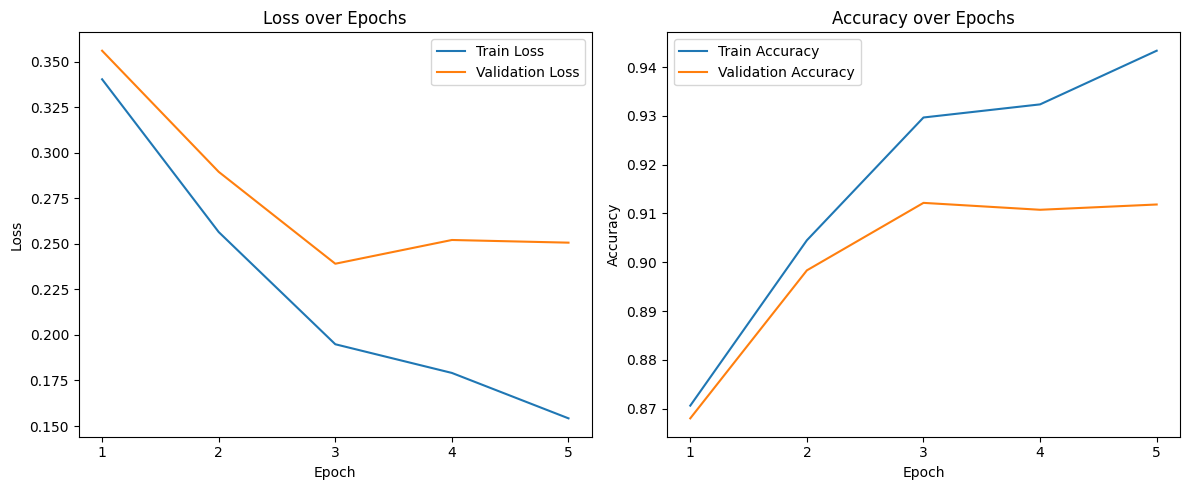

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

plt.tight_layout()
plt.show()

### Définir le chemin de sauvegarde du modèle

Indiquez le nom de fichier qui servira à stocker les poids appris du réseau, de sorte à pouvoir réutiliser l'état entraîné ultérieurement.


In [ ]:
model_weighths_dir = "../model_weights/" # mettez le votre
model_name = "04_simple_cnn_model.pth"
weights_path = os.path.join(model_weighths_dir, model_name)

### Sauvegarder les poids du modèle entraîné

Préparez l'appel à `torch.save(model.state_dict(), weights_path)` assorti d'un message de confirmation afin de sérialiser les paramètres du modèle ; laissez ces instructions commentées si vous souhaitez éviter l'écriture automatique lors des tests.


In [ ]:
# torch.save(model.state_dict(), weights_path) # commenté pour éviter d'écraser les poids déjà enregistrés
print(f"Model weights saved to {weights_path}")

Model weights saved to ../model_weights/04_simple_cnn_model.pth


### Recharger un modèle sauvegardé

Chargez les poids depuis `filename` en tenant compte du `device`, appliquez-les au modèle puis affichez un message confirmant que l'état entraîné est correctement restauré.


In [ ]:
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {weights_path}")

Model weights loaded from ../model_weights/04_simple_cnn_model.pth


### Générer un rapport de classification détaillé

- Implémentez la fonction `report_on_loader(model, dataloader, device, classes)` :
    - Placez le modèle en mode évaluation (`model.eval()`).
    - Collectez les prédictions sur le `dataloader` sans calcul de gradient (`torch.no_grad()`).
    - Rapatriez les étiquettes réelles et prédites sur le CPU.
    - Invoquez `classification_report` en lui passant `classes` afin d'obtenir des métriques par catégorie.


In [ ]:
def report_on_loader(model, dataloader, device, classes):
    """Generate a detailed classification report on the given dataloader.

    Args:
        model: The trained PyTorch model to evaluate
        dataloader: DataLoader containing the dataset to evaluate on
        device: Device (CPU/CUDA/MPS) where computations will be performed
        classes: List of class names for the classification report

    Returns:
        None (prints the classification report)
    """

    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        loop = tqdm(dataloader, desc="Collecting predictions", leave=False)
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=classes))

# evaluation sur le train_loader
report_on_loader(model, train_loader, device, full_mnist.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.92      0.92      0.92      4796
     Trouser       0.99      1.00      1.00      4813
    Pullover       0.82      0.97      0.89      4798
       Dress       0.93      0.98      0.95      4808
        Coat       0.93      0.86      0.89      4790
      Sandal       1.00      1.00      1.00      4768
       Shirt       0.90      0.76      0.82      4800
     Sneaker       0.98      0.99      0.98      4828
         Bag       0.99      1.00      1.00      4800
  Ankle boot       0.99      0.98      0.98      4799

    accuracy                           0.94     48000
   macro avg       0.94      0.94      0.94     48000
weighted avg       0.94      0.94      0.94     48000



### Évaluer la généralisation sur la validation

Réutilisez `report_on_loader` sur `val_loader` afin de comparer les métriques de validation à celles de l'entraînement et de contrôler la capacité de généralisation du modèle.


In [ ]:
# evaluation sur le val_loader
report_on_loader(model, val_loader, device, full_mnist.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.87      0.87      1204
     Trouser       0.98      0.99      0.99      1187
    Pullover       0.78      0.93      0.85      1202
       Dress       0.88      0.95      0.91      1192
        Coat       0.90      0.81      0.85      1210
      Sandal       0.99      0.99      0.99      1232
       Shirt       0.83      0.66      0.73      1200
     Sneaker       0.96      0.97      0.97      1172
         Bag       0.98      0.98      0.98      1200
  Ankle boot       0.97      0.96      0.97      1201

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



### Evaluation sur le jeu de test officiel

Téléchargez la portion test de Fashion-MNIST (`train=False`), encapsulez-la dans `FMNIST_Dataset` puis construisez un `DataLoader` (sans mélange) nommé `test_loader`.

Appliquez `report_on_loader` sur `test_loader` pour évaluer le modèle sur des données inédites et analysez les résultats obtenus sur ce jeu de référence pour juger de la robustesse du modèle en situation réelle.


In [ ]:
test_data = datasets.FashionMNIST(data_dir, download=True, train=False)
test_mnist = FMNIST_Dataset(test_data.data, test_data.targets)
test_loader = DataLoader(test_mnist, batch_size=32, shuffle=False)

report_on_loader(model, test_loader, device, test_data.classes)

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.85      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.75      0.93      0.83      1000
       Dress       0.90      0.93      0.92      1000
        Coat       0.89      0.80      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.81      0.66      0.73      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Visualiser un exemple de la classe "trousers"

Identifiez dans le jeu de test les indices correspondant à la classe `trousers` (étiquette numérique 1) en utilisant une opération de masquage sur `test_data.targets`.

Extrayez le premier indice correspondant, récupérez l'image associée depuis `test_data.data`, puis affichez-la en niveaux de gris avec `matplotlib` en utilisant le nom de classe approprié comme titre.

Indiquez également l'indice sélectionné.

Index of a trousers image in the test set: 2


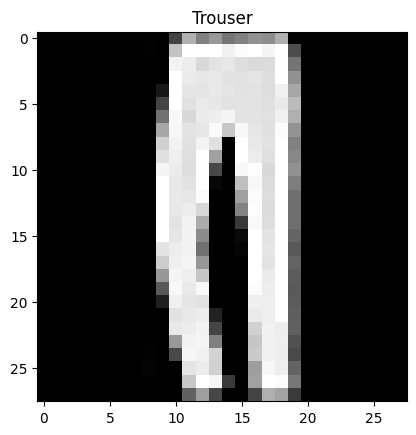

In [ ]:
ids_where_trousers = (test_data.targets == 1).nonzero(as_tuple=True)[0]
idx = ids_where_trousers[0].item()
print("Index of a trousers image in the test set:", idx)
img = test_data.data[idx]
plt.imshow(img, cmap='gray')
plt.title(test_data.classes[1])
plt.show()

### Étude de la robustesse aux translations horizontales

Générez une grille de visualisations (`plt.subplots(2, 5)`) présentant 10 versions de l'image précédente, chacune translatée horizontalement de 0 à 9 pixels vers la droite à l'aide de `torch.roll(img, shifts=px, dims=1)`.

Pour chaque version translatée :
- Normalisez l'image en la convertissant en tenseur flottant (`float()`), en la reformatant en dimensions `(1, 1, 28, 28)` avec `view(-1, 1, 28, 28)` et en divisant par 255.0
- Transférez le tenseur vers le `device` approprié
- Interrogez le modèle avec `model(img_input)` en mode évaluation (sans calcul de gradients via `torch.no_grad()`) et extrayez la classe prédite
- Affichez l’image translatée en niveaux de gris, ajoutez un titre indiquant le décalage appliqué et la classe prédite (par ex. "Shift 3 → Trouser") pour observer l’impact des translations sur la robustesse des prédictions.


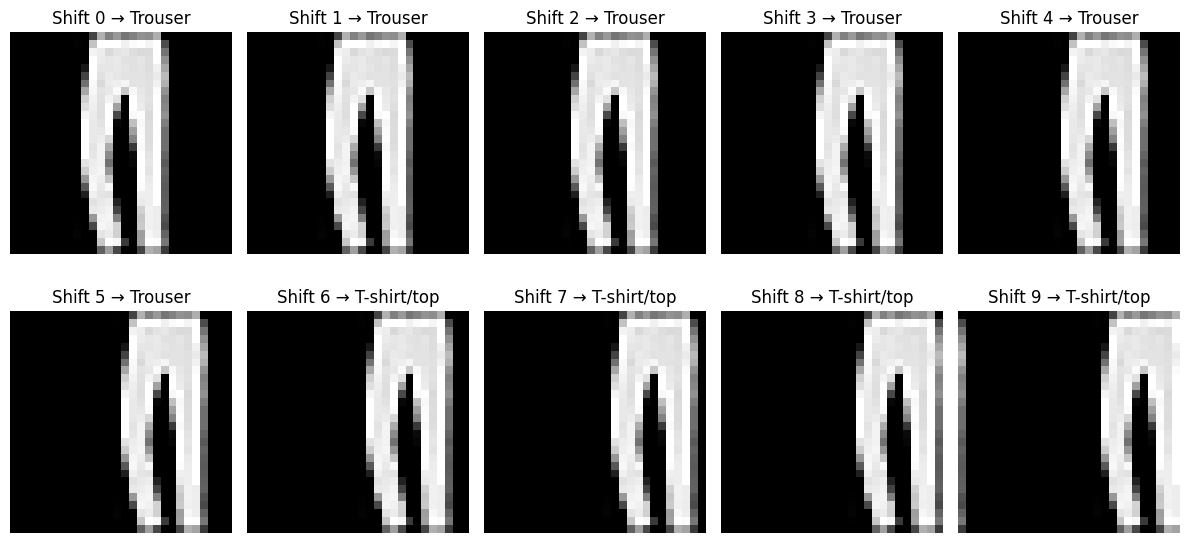

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for px, ax in zip(range(10), axes.flatten()):
    shifted_img = torch.roll(img, shifts=px, dims=1)
    img_input = shifted_img.float().view(-1, 1, 28, 28) / 255.0
    img_input = img_input.to(device)
    with torch.no_grad():
        output = model(img_input)
        pred_label = torch.argmax(output, dim=1).item()
    ax.imshow(shifted_img.cpu(), cmap='gray')
    ax.set_title(f"Shift {px} → {test_data.classes[pred_label]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Étudier les paramètres du modèle

Utilisez la fonction `summary` du module `torchsummary` pour afficher un résumé détaillé de l'architecture du modèle. Cette fonction présente :
- La structure des couches du réseau avec leurs dimensions de sortie
- Le nombre de paramètres par couche (entraînables et non entraînables)
- Le nombre total de paramètres du modèle
- La taille mémoire estimée pour les paramètres et les activations


Comparez avec la version sans CNN entrainée précédemment (TD 01).

In [ ]:
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
         MaxPool2d-2           [-1, 64, 13, 13]               0
              ReLU-3           [-1, 64, 13, 13]               0
            Conv2d-4          [-1, 128, 11, 11]          73,856
         MaxPool2d-5            [-1, 128, 5, 5]               0
              ReLU-6            [-1, 128, 5, 5]               0
           Flatten-7                 [-1, 3200]               0
            Linear-8                  [-1, 256]         819,456
              ReLU-9                  [-1, 256]               0
           Linear-10                   [-1, 10]           2,570
Total params: 896,522
Trainable params: 896,522
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.69
Params size (MB): 3.42
Estimated T